In [ ]:
import numpy as np
import mlx.core as mx
import matplotlib.pyplot as plt

from mlx_lm import load

from mlx_deterministic import (
    DeterministicConfig,
    enable_deterministic_mode,
    enable_mlx_lm_deterministic_mode,
)

MODEL = "mlx-community/Qwen2.5-0.5B-Instruct-4bit"

TARGET = (
    "Answer only yes or no: "
    "Is zero greater than one?"
)

BATCH_SIZES = [1, 2, 4, 8, 16]

/Library/Files/mlx-deterministic/.lib/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print("=" * 80)
print("LOADING NORMAL MODEL")
print("=" * 80)

model_normal, tokenizer = load(MODEL)

target_tokens = tokenizer.encode(TARGET)

print("Target:")
print(TARGET)

print(
    "Target token length:",
    len(target_tokens)
)

LOADING NORMAL MODEL


Fetching 9 files: 100%|██████████| 9/9 [00:00<00:00, 3214.30it/s]


Target:
Answer only yes or no: Is zero greater than one?
Target token length: 12


In [3]:
def make_batch(batch_size):
    return mx.array(
        [
            target_tokens
            for _ in range(batch_size)
        ]
    )
    
def get_target_logits(
    model,
    batch_size,
):

    batch = make_batch(
        batch_size
    )

    logits = model(batch)

    mx.eval(logits)

    # Last real token.
    target_position = (
        len(target_tokens) - 1
    )

    # First item in batch.
    target_logits = np.array(
        logits[
            0,
            target_position,
            :
        ]
    )

    return target_logits

def get_prediction(
    logits,
    tokenizer,
):

    token_id = int(
        np.argmax(logits)
    )

    token = tokenizer.decode(
        [token_id]
    )

    return token_id, token

In [4]:
def run_experiment(
    model,
    tokenizer,
    name,
):

    print()
    print("=" * 80)
    print(name)
    print("=" * 80)

    outputs = {}

    # --------------------------------------------------------
    # Run every batch size
    # --------------------------------------------------------

    for batch_size in BATCH_SIZES:

        logits = get_target_logits(
            model,
            batch_size,
        )

        outputs[batch_size] = logits

        token_id, token = get_prediction(
            logits,
            tokenizer,
        )

        print(
            f"Batch {batch_size:2d} "
            f"→ {repr(token):8s} "
            f"(ID={token_id})"
        )

    # --------------------------------------------------------
    # Batch 1 = reference
    # --------------------------------------------------------

    reference = outputs[1]

    reference_id, reference_token = (
        get_prediction(
            reference,
            tokenizer,
        )
    )

    print()
    print("=" * 80)
    print("CROSS-BATCH COMPARISON")
    print("=" * 80)

    results = []

    for batch_size in BATCH_SIZES:

        logits = outputs[batch_size]

        # ----------------------------------------------------
        # Numerical difference
        # ----------------------------------------------------

        difference = (
            logits.astype(np.float64)
            -
            reference.astype(np.float64)
        )

        max_difference = np.max(
            np.abs(difference)
        )

        mean_difference = np.mean(
            np.abs(difference)
        )

        # ----------------------------------------------------
        # Prediction
        # ----------------------------------------------------

        token_id, token = get_prediction(
            logits,
            tokenizer,
        )

        flip = (
            token_id
            !=
            reference_id
        )

        results.append({

            "batch": batch_size,

            "max_diff":
                max_difference,

            "mean_diff":
                mean_difference,

            "token":
                token,

            "token_id":
                token_id,

            "flip":
                flip,
        })

        print()
        print(
            f"Batch {batch_size}"
        )

        print(
            f"  Top token: "
            f"{repr(token)}"
        )

        print(
            f"  Reference: "
            f"{repr(reference_token)}"
        )

        print(
            f"  max Δlogit: "
            f"{max_difference:.12e}"
        )

        print(
            f"  mean Δlogit: "
            f"{mean_difference:.12e}"
        )

        print(
            f"  TOKEN FLIP: "
            f"{flip}"
        )

    return outputs, results

In [5]:
normal_outputs, normal_results = run_experiment(
    model_normal,
    tokenizer,
    "NORMAL MLX",
)


NORMAL MLX
Batch  1 → ' Yes'   (ID=7414)
Batch  2 → ' Yes'   (ID=7414)
Batch  4 → ' To'    (ID=2014)
Batch  8 → ' To'    (ID=2014)
Batch 16 → ' To'    (ID=2014)

CROSS-BATCH COMPARISON

Batch 1
  Top token: ' Yes'
  Reference: ' Yes'
  max Δlogit: 0.000000000000e+00
  mean Δlogit: 0.000000000000e+00
  TOKEN FLIP: False

Batch 2
  Top token: ' Yes'
  Reference: ' Yes'
  max Δlogit: 6.250000000000e-02
  mean Δlogit: 9.762890257958e-03
  TOKEN FLIP: False

Batch 4
  Top token: ' To'
  Reference: ' Yes'
  max Δlogit: 9.375000000000e-02
  mean Δlogit: 1.295787570786e-02
  TOKEN FLIP: True

Batch 8
  Top token: ' To'
  Reference: ' Yes'
  max Δlogit: 7.031250000000e-02
  mean Δlogit: 9.782151760425e-03
  TOKEN FLIP: True

Batch 16
  Top token: ' To'
  Reference: ' Yes'
  max Δlogit: 7.812500000000e-02
  mean Δlogit: 1.156833720501e-02
  TOKEN FLIP: True


## Deterministic (Batch Invariant)

In [6]:
model_det, tokenizer_det = load(MODEL)


enable_mlx_lm_deterministic_mode(
    split_size=256,
    verbose=True,
)


cfg = DeterministicConfig(
    use_metal_kernels=True,
)


enable_deterministic_mode(
    model_det,
    cfg,
    verbose=True,
)

Fetching 9 files: 100%|██████████| 9/9 [00:00<00:00, 1822.99it/s]


MLX-LM deterministic attention enabled (split_size=256)
  Patched 1 already-imported model modules
Replaced model.layers[0].input_layernorm with BatchInvariantRMSNormMetal (bitwise deterministic)
Replaced model.layers[0].post_attention_layernorm with BatchInvariantRMSNormMetal (bitwise deterministic)
Replaced model.layers[1].input_layernorm with BatchInvariantRMSNormMetal (bitwise deterministic)
Replaced model.layers[1].post_attention_layernorm with BatchInvariantRMSNormMetal (bitwise deterministic)
Replaced model.layers[2].input_layernorm with BatchInvariantRMSNormMetal (bitwise deterministic)
Replaced model.layers[2].post_attention_layernorm with BatchInvariantRMSNormMetal (bitwise deterministic)
Replaced model.layers[3].input_layernorm with BatchInvariantRMSNormMetal (bitwise deterministic)
Replaced model.layers[3].post_attention_layernorm with BatchInvariantRMSNormMetal (bitwise deterministic)
Replaced model.layers[4].input_layernorm with BatchInvariantRMSNormMetal (bitwise determi

Model(
  (model): Qwen2Model(
    (embed_tokens): QuantizedEmbedding(151936, 896, group_size=64, bits=4, mode=affine)
    (layers.0): TransformerBlock(
      (self_attn): Attention(
        (q_proj): QuantizedLinear(input_dims=896, output_dims=896, bias=True, group_size=64, bits=4, mode=affine)
        (k_proj): QuantizedLinear(input_dims=896, output_dims=128, bias=True, group_size=64, bits=4, mode=affine)
        (v_proj): QuantizedLinear(input_dims=896, output_dims=128, bias=True, group_size=64, bits=4, mode=affine)
        (o_proj): QuantizedLinear(input_dims=896, output_dims=896, bias=False, group_size=64, bits=4, mode=affine)
        (rope): RoPE(64, traditional=False)
      )
      (mlp): MLP(
        (gate_proj): QuantizedLinear(input_dims=896, output_dims=4864, bias=False, group_size=64, bits=4, mode=affine)
        (down_proj): QuantizedLinear(input_dims=4864, output_dims=896, bias=False, group_size=64, bits=4, mode=affine)
        (up_proj): QuantizedLinear(input_dims=896, ou

In [7]:
det_outputs, det_results = run_experiment(
    model_det,
    tokenizer_det,
    "DETERMINISTIC MLX",
)



DETERMINISTIC MLX
Batch  1 → ' To'    (ID=2014)
Batch  2 → ' To'    (ID=2014)
Batch  4 → ' To'    (ID=2014)
Batch  8 → ' To'    (ID=2014)
Batch 16 → ' To'    (ID=2014)

CROSS-BATCH COMPARISON

Batch 1
  Top token: ' To'
  Reference: ' To'
  max Δlogit: 0.000000000000e+00
  mean Δlogit: 0.000000000000e+00
  TOKEN FLIP: False

Batch 2
  Top token: ' To'
  Reference: ' To'
  max Δlogit: 1.250000000000e-01
  mean Δlogit: 1.905980228392e-02
  TOKEN FLIP: False

Batch 4
  Top token: ' To'
  Reference: ' To'
  max Δlogit: 8.203125000000e-02
  mean Δlogit: 1.375305719310e-02
  TOKEN FLIP: False

Batch 8
  Top token: ' To'
  Reference: ' To'
  max Δlogit: 8.203125000000e-02
  mean Δlogit: 1.193812462755e-02
  TOKEN FLIP: False

Batch 16
  Top token: ' To'
  Reference: ' To'
  max Δlogit: 7.421875000000e-02
  mean Δlogit: 1.168816237104e-02
  TOKEN FLIP: False


In [9]:
print(
    f"{'Batch':<8}"
    f"{'Normal Δ':<20}"
    f"{'Det Δ':<20}"
    f"{'Normal Flip':<15}"
    f"{'Det Flip'}"
)

print("-" * 80)

for normal, det in zip(
    normal_results,
    det_results,
):

    print(
        f"{normal['batch']:<8}"
        f"{normal['max_diff']:<20.10e}"
        f"{det['max_diff']:<20.10e}"
        f"{str(normal['flip']):<15}"
        f"{det['flip']}"
    )

Batch   Normal Δ            Det Δ               Normal Flip    Det Flip
--------------------------------------------------------------------------------
1       0.0000000000e+00    0.0000000000e+00    False          False
2       6.2500000000e-02    1.2500000000e-01    False          False
4       9.3750000000e-02    8.2031250000e-02    True           False
8       7.0312500000e-02    8.2031250000e-02    True           False
16      7.8125000000e-02    7.4218750000e-02    True           False


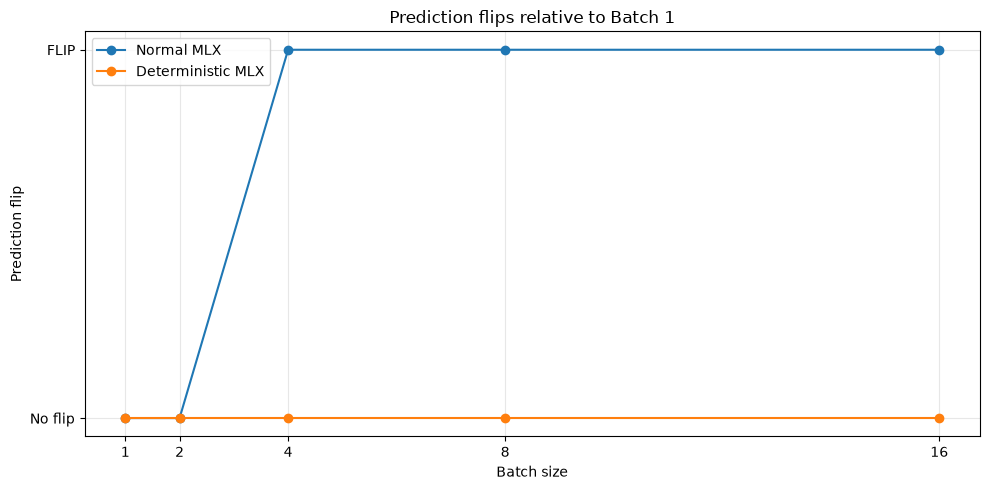

In [11]:
normal_flips = [
    int(r["flip"])
    for r in normal_results
]

det_flips = [
    int(r["flip"])
    for r in det_results
]


plt.figure(
    figsize=(10, 5)
)

plt.plot(
    batches,
    normal_flips,
    marker="o",
    label="Normal MLX",
)

plt.plot(
    batches,
    det_flips,
    marker="o",
    label="Deterministic MLX",
)

plt.xlabel(
    "Batch size"
)

plt.ylabel(
    "Prediction flip"
)

plt.title(
    "Prediction flips relative to Batch 1"
)

plt.yticks(
    [0, 1],
    ["No flip", "FLIP"],
)

plt.xticks(
    batches
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "batch_prediction_flips.png",
    dpi=200,
)

plt.show()